<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_2_Benchmarking_Classification_Algorithms_for_Credit_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: PD Algorithm Benchmark
*Credit risk project on Lending Club loans: Part 2 of 5*

## Project map

| Part | Topic | Main question | Main output |
|---|---|---|---|
| 0 | Data Foundation | What data do we need, and how do we prepare it? | Clean loan table and macro data |
| 1 | Loss Given Default (LGD) | How much do we lose when a borrower defaults? | LGD by grade and downturn LGD |
| **2** | **PD Algorithm Benchmark (this part)** | **Which model predicts default best?** | **Choice of PD model** |
| 3 | PD Scorecard and Credit Decisions | How do we build, check and use a PD model? | Calibrated PD, score, cut-off, stability check |
| 4 | Macroeconomic Stress Testing | How much would the portfolio lose in a recession? | 9-quarter loss by scenario |
| 5 | Forward Flow and Securitization | Did the purchased loans perform as expected, and who carries the loss? | Monitoring, waterfall, tranche break-even |

The whole project is built around the expected loss formula, $EL = PD \times LGD \times EAD$. Part 1 measures LGD, Parts 2 and 3 measure PD, and Parts 4 and 5 add EAD, the economy and the investor view.

## What this part does

Part 1 measured how much a lender loses when a borrower defaults. Parts 2 and 3 now measure the other side: **will the borrower default?** In this part, we compare seven machine learning and statistical methods on the same task: predicting whether a loan will default. We also compare them with Lending Club's own credit grade, which is the lender's internal risk rating.

## How it connects to the other parts

* **Uses:** the clean loan table from Part 0 (`lc_clean.pkl`).
* **Feeds:** Part 3 builds the full PD model with the two most useful methods found here: a logistic regression scorecard (easy to explain) and LightGBM (the most accurate). Part 5 uses Lending Club's sub-grade as the underwriting PD, because this benchmark shows it ranks borrowers best.

## Why it matters for credit risk

The probability of default (PD) is the other main input of expected loss, next to the LGD from Part 1. A lender uses it to approve or reject applicants, to set the interest rate, and to calculate provisions and capital. In a bank, a new model must be compared with other methods before it is approved. This process is called **benchmarking**, and model validation teams expect it.

## Methodology

1. **Sample and target.** We use 36-month loans issued 2010–2015. They all reached the end of their term before the snapshot date, so we know every outcome. Default = the loan was charged off.
2. **Out-of-time test.** Models learn from loans issued 2010–2014 and are tested on loans issued in 2015. This is how a model is used in real life: built on the past, applied to new customers.
3. **Only application data.** We exclude Lending Club's own grade, sub-grade and interest rate, because they are the lender's risk rating. We keep them as an **external benchmark**. We also exclude the borrower's state, because location can act as a proxy for protected characteristics.
4. **Data prepared for each method.** Tree models use raw data. Logistic regression uses Weight of Evidence (WOE) values. LASSO and SVM use standardized data.
5. **Metrics.** ROC-AUC, Gini and KS measure how well a model ranks borrowers. The Brier score measures how accurate the probabilities are. We also record training time.

## Main results

* **Gradient boosting ranks borrowers best:** XGBoost (AUC 0.671), LightGBM (0.670) and CatBoost (0.670). They beat the WOE logistic scorecard (0.653) by about 0.017 AUC.
* **Lending Club's own sub-grade (AUC 0.679) beats every model.** The lender had credit bureau data that is not in the public file. Our best model is 0.008 AUC behind it.
* **All models predict too few defaults for 2015** (about 13.4% on average vs. 14.9% actual), because the 2015 loans were riskier than the 2010–2014 loans.
* **SVM is not practical at this size.** It needed 423 seconds for only 20,000 loans and had the lowest AUC (0.554).

Tech stack: Python, pandas, scikit-learn, LightGBM, XGBoost, CatBoost, scorecardpy, SciPy, Matplotlib, Google Colab.

# Step 1: Setup and Data Loading

**Why this step?** We load the clean loan table from Part 0, so this part uses exactly the same data and default definition as the rest of the project.

**How we do it.** We mount Google Drive and read the folder path from the Colab secret `credit_ris_DIR`. CatBoost and scorecardpy are not installed in Colab by default, so the cell installs them if needed.

In [ ]:
try:
    import scorecardpy as sc
except ImportError:
    !pip install scorecardpy
    import scorecardpy as sc
try:
    from catboost import CatBoostClassifier
except ImportError:
    !pip install catboost
    from catboost import CatBoostClassifier
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from xgboost import XGBClassifier
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')   # Colab secret that holds the Drive folder path

# 1.2. Load the Part 0 output
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
print(f"Loans loaded: {len(lc):,}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60724 sha256=6699d059d60755968a7aa0a2818f7313ddc687edf9d9a2b050877dbd527f216d
  Stored in directory: /root/.cache/pip/wheels/d7/a8/fb/593dcef7717ee8a731e22872353b598d8d8bef4ee405a1c54a
Successfully built scorecardpy


/usr/local/lib/python3.13/dist-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
Mounted at /content/drive
Loans loaded: 2,260,668


# Step 2: Target Definition and Out-of-Time Sample

**Why this step?** A PD model must learn from loans with a **known** outcome. A loan that is still running cannot be called "good", because it may still default. If we included such loans, the model would learn a default rate that is too low.

**How we do it.**
* We select **36-month loans issued 2010–2015**. The last of them ended in December 2018, before the March 2019 snapshot, so almost all outcomes are known. We start in 2010 because Lending Club was very small before that and used a different credit policy.
* The target is `TARGET = 1` for a charged-off loan and 0 for a repaid loan. The few loans still open are dropped, and the code prints their share so we can check that this is harmless.
* We add two affordability ratios: **loan-to-income** (loan amount ÷ annual income) and **revolving-debt-to-income** (card balances ÷ annual income).
* **Out-of-time split:** training = loans issued 2010–2014; test = loans issued in 2015.

In [ ]:
print("--- Building the Modeling Sample ---")

# 1. 36-month loans issued 2010-2015
base = lc[(lc['term_m'] == 36) & lc['issue_year'].between(2010, 2015)].copy()
still_open = (~base['outcome'].isin(['default', 'paid'])).mean()
print(f"36-month loans issued 2010-2015: {len(base):,} ({still_open:.2%} still open -> dropped)")

# 2. Completed loans and binary target
df = base[base['outcome'].isin(['default', 'paid'])].copy()
df['TARGET'] = (df['outcome'] == 'default').astype(int)

# 3. Engineered affordability features (all known at application)
income = df['annual_inc'].where(df['annual_inc'] > 0)
df['log_annual_inc'] = np.log1p(df['annual_inc'].clip(lower=0))
df['loan_to_income'] = df['loan_amnt'] / income                 # loan size relative to earnings
df['revol_bal_to_income'] = df['revol_bal'] / income             # revolving debt burden

NUM_FEATURES = ['fico', 'dti', 'log_annual_inc', 'loan_to_income', 'revol_bal_to_income', 'revol_util',
                'loan_amnt', 'emp_years', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
                'total_acc', 'mort_acc']
CAT_FEATURES = ['home_ownership', 'verification_status', 'purpose']
FEATURES = NUM_FEATURES + CAT_FEATURES

# 4. Out-of-time split
train = df[df['issue_year'] <= 2014].reset_index(drop=True)
test = df[df['issue_year'] == 2015].reset_index(drop=True)
y_train, y_test = train['TARGET'].values, test['TARGET'].values

print(f"\nTrain (2010-2014): {len(train):,} loans | default rate {y_train.mean():.2%}")
print(f"Test  (2015):      {len(test):,} loans | default rate {y_test.mean():.2%}")
display(df.groupby('issue_year')['TARGET'].agg(['size', 'mean']).rename(columns={'size': 'Loans', 'mean': 'Default Rate'}))

--- Building the Modeling Sample ---
36-month loans issued 2010-2015: 612,892 (0.02% still open -> dropped)

Train (2010-2014): 329,719 loans | default rate 13.07%
Test  (2015):      283,026 loans | default rate 14.89%


,Loans,Default Rate
issue_year,,
2010,9156,0.109218
2011,14101,0.106305
2012,43470,0.135795
2013,100422,0.123260
2014,162570,0.137264
2015,283026,0.148863


### Results

* The sample has **612,745 finished 36-month loans**. Only 0.02% of the loans issued 2010–2015 were still open, so dropping them does not bias the target.
* **Training set:** 329,719 loans (2010–2014), default rate **13.07%**. **Test set:** 283,026 loans (2015), default rate **14.89%**.
* Default rate by issue year: 10.9% (2010), 10.6% (2011), 13.6% (2012), 12.3% (2013), 13.7% (2014), 14.9% (2015).
* **The test year is riskier than the training years.** This is called a population shift. We should expect the models to rank borrowers well but to predict too few defaults.

# Step 3: Data Preparation for Each Method (WOE)

**Why this step?** Each family of methods needs the data in a different form. If we give all methods the same raw data, the comparison is not fair.

**How we do it.**
* **Stream A, tree models** (Random Forest, LightGBM, XGBoost, CatBoost): raw numbers, with missing values kept, plus one column per category (one-hot encoding). Trees can split on raw values and handle missing values.
* **Stream B, logistic regression:** Weight of Evidence (WOE) values. We cut each variable into bins and replace each bin with its WOE:
$$WOE_b = \ln\left(\frac{\%\text{Bad}_b}{\%\text{Good}_b}\right), \qquad IV = \sum_b (\%\text{Bad}_b - \%\text{Good}_b)\cdot WOE_b$$
WOE puts missing values in their own bin, makes the link with the log-odds of default linear, and reduces the effect of outliers. The Information Value (IV) measures how strongly a variable separates defaulters from non-defaulters. **The bins are learned on the training set only** and then applied to the test set, so no test information leaks into the model. A test value that never appeared in training gets WOE = 0, which means average risk.
* **Stream C, LASSO and SVM:** missing values replaced by the median, then standardized. These methods use distances or penalties, so all variables must be on the same scale.

In [ ]:
print("--- Preparing Data Streams ---")

# Stream A: raw features + one-hot categories (tree models)
def one_hot(frame, reference_columns=None):
    X = pd.get_dummies(frame[FEATURES], columns=CAT_FEATURES, dummy_na=False, dtype=float)
    X.columns = [c.replace(' ', '_') for c in X.columns]
    return X if reference_columns is None else X.reindex(columns=reference_columns, fill_value=0.0)

X_train_tree = one_hot(train)
X_test_tree = one_hot(test, X_train_tree.columns)

# Stream B: WOE binning fitted on the training set only (no leakage)
print("Calculating WOE bins on the training set (this may take a minute)...")
bins = sc.woebin(train[FEATURES + ['TARGET']], y='TARGET')

def apply_woe(frame, bins_dict, label):
    """Apply WOE bins. Values never seen in training (e.g. a new category in 2015, or a missing value
    in a feature that had none in training) have no bin and come back as NaN. They receive WOE = 0,
    i.e. the average risk of the training population -- the neutral, standard treatment."""
    X = sc.woebin_ply(frame[list(bins_dict) + ['TARGET']], bins_dict).drop(columns='TARGET')
    unmatched = X.isna().sum()
    if unmatched.sum() > 0:
        print(f"{label}: values without a training bin -> WOE set to 0: {unmatched[unmatched > 0].to_dict()}")
    return X.fillna(0.0)

X_train_woe = apply_woe(train, bins, 'Train')
X_test_woe = apply_woe(test, bins, 'Test (2015)')

iv_df = pd.DataFrame({'Information Value (IV)': {k: v['total_iv'].iloc[0] for k, v in bins.items()}})
iv_df = iv_df.sort_values('Information Value (IV)', ascending=False)
print("\n--- Feature Information Value (IV) ---")
print("Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)")
display(iv_df.round(4))

# Stream C: imputed + standardized (LASSO, SVM)
medians = X_train_tree.median()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_tree.fillna(medians))
X_test_scaled = scaler.transform(X_test_tree.fillna(medians))

print(f"\nStream A: {X_train_tree.shape[1]} columns | Stream B: {X_train_woe.shape[1]} WOE columns | "
      f"Stream C: {X_train_scaled.shape[1]} columns")

--- Preparing Data Streams ---
Calculating WOE bins on the training set (this may take a minute)...
[INFO] creating woe binning ...
Binning on 329719 rows and 18 columns in 00:00:54
[INFO] converting into woe values ...
Woe transformating on 329719 rows and 17 columns in 00:00:16
[INFO] converting into woe values ...
Woe transformating on 283026 rows and 17 columns in 00:00:14
Test (2015): values without a training bin -> WOE set to 0: {'dti_woe': 2, 'loan_to_income_woe': 2, 'revol_bal_to_income_woe': 2}

--- Feature Information Value (IV) ---
Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)


,Information Value (IV)
fico,0.1373
log_annual_inc,0.0821
dti,0.0461
mort_acc,0.0435
loan_to_income,0.0417
home_ownership,0.0371
inq_last_6mths,0.0300
revol_util,0.0248
purpose,0.0217
emp_years,0.0174



Stream A: 37 columns | Stream B: 17 WOE columns | Stream C: 37 columns


### Results

* Binning 329,719 training loans took less than a minute. Only 6 test values were outside the training bins, so the neutral WOE of 0 has no real effect.
* **Only FICO has medium strength** (IV = 0.137). Lending Club had already screened its applicants, so approved borrowers are quite similar to each other. This limits what any model can achieve.
* **Weak but useful variables** (IV 0.02–0.1): income (0.082), DTI (0.046), number of mortgage accounts (0.044), loan-to-income (0.042), home ownership (0.037), credit inquiries in the last 6 months (0.030), revolving utilization (0.025) and loan purpose (0.022).
* **Loan-to-income is stronger than the raw loan amount** (0.042 vs. 0.010). The size of the loan matters less than its size compared with income.
* **Almost useless variables** (IV < 0.02): employment length, loan amount, total accounts, income verification, revolving-debt-to-income, public records, past delinquencies and open accounts. Past delinquencies are rare among approved Lending Club borrowers, so they barely separate the groups. Part 3 keeps only the 9 variables with IV ≥ 0.02.

# Model Review: Methods and Math
1. Logistic Regression
Explanation: This foundational parametric model predicts probabilities by fitting data to a logistic curve. It assumes a linear relationship between the features and the log-odds of default, which is why it is paired with WOE-transformed inputs. Its coefficients translate directly into scorecard points.
Math:
$$p = \frac{1}{1 + e^{-(\beta_0 + \sum_{i=1}^{n} \beta_i x_i)}}$$
Best Dataset: Small to medium datasets requiring high interpretability and regulatory acceptance (traditional banking scorecards).

2. LASSO (L1-Penalized Logistic Regression)
Explanation: LASSO adds an $L_1$ penalty that shrinks the coefficients of weak predictors to exactly zero, which performs automatic feature selection. It requires standardized data, so that the penalty treats all features equally.
Math:
$$\min_{\beta_0, \beta} \left[ -\frac{1}{N} \sum_{i=1}^N \big(y_i \log p_i + (1-y_i)\log(1-p_i)\big) + \lambda \sum_{j=1}^p \lvert\beta_j\rvert \right]$$
Best Dataset: High-dimensional data with many redundant features, where a sparse, interpretable model is needed.

3. Support Vector Machine (SVM)
Explanation: SVM finds the hyperplane that maximizes the margin between the classes, and uses kernels for non-linear boundaries. Training time grows roughly quadratically with the number of observations, so it is trained on a **20,000-loan subsample**. Its probabilities come from an internal Platt scaling.
Math:
$$\min_{w,b,\xi}\; \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^n \xi_i \quad \text{s.t.} \quad y_i(w \cdot \phi(x_i) + b) \geq 1 - \xi_i,\; \xi_i \ge 0$$
Best Dataset: Small, complex datasets with non-linear boundaries.

4. Random Forest
Explanation: An ensemble of deep, independent decision trees, each trained on a bootstrap sample with a random subset of features (bagging). Averaging many trees reduces variance.
Math:
$$\hat{f}_{rf}(x) = \frac{1}{B} \sum_{b=1}^B T_b(x)$$
Best Dataset: Medium to large datasets needing a strong, low-maintenance baseline.

5. LightGBM
Explanation: A gradient-boosting framework that grows trees leaf-wise and uses histogram binning for speed. It handles missing values natively.
Math:
$$F_m(x) = F_{m-1}(x) + \nu \, h_m(x)$$
Best Dataset: Large tabular datasets that require speed and accuracy.

6. XGBoost
Explanation: Gradient boosting with level-wise tree growth and an explicit penalty on tree complexity to control overfitting.
Math:
$$\mathcal{L}^{(t)} = \sum_{i=1}^n l\left(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)\right) + \gamma T + \tfrac{1}{2}\lambda \lVert w \rVert^2$$
Best Dataset: Tabular data where robust regularization matters more than raw speed.

7. CatBoost
Explanation: Gradient boosting with symmetric (oblivious) trees and ordered target statistics for categorical variables, which prevents target leakage in the encoding.
Math:
$$\hat{x}_k = \frac{\sum_{j=1}^{i-1} [x_j = x_k]\, y_j + a \cdot P}{\sum_{j=1}^{i-1} [x_j = x_k] + a}$$
Best Dataset: Data dominated by high-cardinality categorical variables.

**Evaluation Metrics**

| Metric | Definition | What it measures |
|---|---|---|
| ROC-AUC | $P(\hat p_{\text{bad}} > \hat p_{\text{good}})$ | rank-ordering power |
| Gini | $2 \times AUC - 1$ | the same, on the scale banks report |
| KS | $\max_s \lvert F_{\text{bad}}(s) - F_{\text{good}}(s)\rvert$ | maximum separation of the two score distributions |
| Brier score | $\frac{1}{N}\sum (y_i - \hat p_i)^2$ | accuracy of the probability *levels* (calibration and sharpness); lower is better |

# Step 4: Train, Predict and Compare

**Why this step?** This is the benchmark itself. All seven methods learn from the same 2010–2014 loans and are scored on the same unseen 2015 loans.

**How we do it.** We train each model, predict the default probability of every 2015 loan, and record AUC, Gini, KS, Brier score and training time. SVM trains on a random sample of 20,000 loans, because its training time grows very fast with the number of loans.

**External benchmark.** We also score the 2015 loans with Lending Club's **sub-grade** (A1 to G5): each sub-grade gets its default rate in the training period. This answers a practical question: *can our model rank borrowers better than the lender's own grading?*

--- Training Models & Evaluating on the 2015 Vintage ---
Training 1. Logistic Reg (WOE Scorecard)... Done! (AUC: 0.6530, Time: 1.7s)
Training 2. LASSO (L1 Penalized Reg)... Done! (AUC: 0.6566, Time: 2.5s)
Training 3. Random Forest (Bagging)... Done! (AUC: 0.6598, Time: 114.4s)
Training 4. LightGBM (Boosting)... Done! (AUC: 0.6700, Time: 18.3s)
Training 5. XGBoost (Boosting)... Done! (AUC: 0.6707, Time: 19.0s)
Training 6. CatBoost (Boosting)... Done! (AUC: 0.6699, Time: 27.3s)
Training 7. SVM (RBF, 20k subsample)... Done! (AUC: 0.5542, Time: 422.5s)

Actual 2015 default rate: 14.89%

--- Final Model Benchmark Comparison (Out-of-Time: 2015 Vintage) ---


,Model,ROC-AUC,Gini,KS,Brier Score,Mean PD,Training Time (s)
0,Benchmark: Lending Club Sub-Grade,0.6786,0.3573,26.1942,0.1211,0.1279,NaN
1,5. XGBoost (Boosting),0.6707,0.3415,24.8495,0.1211,0.1348,19.0254
2,4. LightGBM (Boosting),0.6700,0.3401,24.7315,0.1211,0.1348,18.3202
3,6. CatBoost (Boosting),0.6699,0.3399,24.5757,0.1212,0.1342,27.3313
4,3. Random Forest (Bagging),0.6598,0.3195,23.2543,0.1223,0.1330,114.3965
5,2. LASSO (L1 Penalized Reg),0.6566,0.3133,22.6054,0.1222,0.1335,2.5266
6,1. Logistic Reg (WOE Scorecard),0.6530,0.3060,21.9538,0.1223,0.1326,1.6700
7,"7. SVM (RBF, 20k subsample)",0.5542,0.1084,8.8395,0.1268,0.1288,422.5073


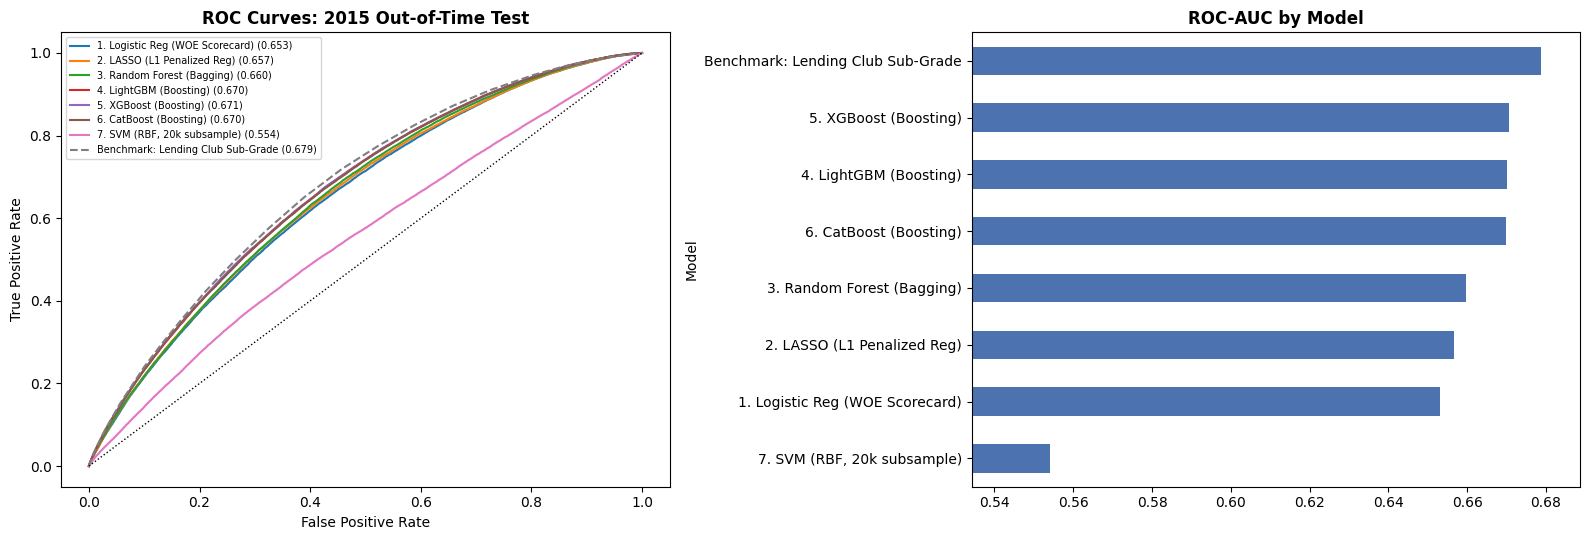

In [ ]:
print("--- Training Models & Evaluating on the 2015 Vintage ---")

def ks_stat(y, p):
    return ks_2samp(p[y == 1], p[y == 0]).statistic * 100

# 1. SVM subsample (training time grows ~quadratically with n)
svm_idx = np.random.default_rng(42).choice(len(train), size=min(20000, len(train)), replace=False)

models = {
    "1. Logistic Reg (WOE Scorecard)": (LogisticRegression(C=0.1, max_iter=1000), X_train_woe, X_test_woe, None),
    "2. LASSO (L1 Penalized Reg)": (LogisticRegression(penalty='l1', solver='liblinear', C=0.01), X_train_scaled, X_test_scaled, None),
    "3. Random Forest (Bagging)": (RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50, n_jobs=-1, random_state=42),
                                   X_train_tree.fillna(-999), X_test_tree.fillna(-999), None),
    "4. LightGBM (Boosting)": (lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
                               X_train_tree, X_test_tree, None),
    "5. XGBoost (Boosting)": (XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='auc'),
                              X_train_tree, X_test_tree, None),
    "6. CatBoost (Boosting)": (CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, random_state=42, verbose=0),
                               X_train_tree, X_test_tree, None),
    "7. SVM (RBF, 20k subsample)": (SVC(probability=True, random_state=42), X_train_scaled, X_test_scaled, svm_idx),
}

results, test_preds = [], {}
for name, (model, X_tr, X_te, subsample) in models.items():
    start = time.time()
    print(f"Training {name}...", end=" ")
    if subsample is not None:
        model.fit(X_tr[subsample], y_train[subsample])
    else:
        model.fit(X_tr, y_train)
    p = model.predict_proba(X_te)[:, 1]
    elapsed = time.time() - start
    auc = roc_auc_score(y_test, p)
    test_preds[name] = p
    results.append({'Model': name, 'ROC-AUC': auc, 'Gini': 2 * auc - 1, 'KS': ks_stat(y_test, p),
                    'Brier Score': brier_score_loss(y_test, p), 'Mean PD': p.mean(), 'Training Time (s)': elapsed})
    print(f"Done! (AUC: {auc:.4f}, Time: {elapsed:.1f}s)")

# 2. External benchmark: Lending Club's own sub-grade
subgrade_pd = train.groupby('sub_grade')['TARGET'].mean()
p_lc = test['sub_grade'].map(subgrade_pd).fillna(y_train.mean()).values
auc_lc = roc_auc_score(y_test, p_lc)
test_preds["Benchmark: Lending Club Sub-Grade"] = p_lc
results.append({'Model': "Benchmark: Lending Club Sub-Grade", 'ROC-AUC': auc_lc, 'Gini': 2 * auc_lc - 1,
                'KS': ks_stat(y_test, p_lc), 'Brier Score': brier_score_loss(y_test, p_lc),
                'Mean PD': p_lc.mean(), 'Training Time (s)': np.nan})

# 3. Final comparison table
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(f"\nActual 2015 default rate: {y_test.mean():.2%}")
print("\n--- Final Model Benchmark Comparison (Out-of-Time: 2015 Vintage) ---")
display(results_df.round(4))

# 4. ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for name, p in test_preds.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_test, p):.3f})", ls='--' if 'Benchmark' in name else '-')
axes[0].plot([0, 1], [0, 1], 'k:', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves: 2015 Out-of-Time Test', fontweight='bold'); axes[0].legend(fontsize=7)
results_df.set_index('Model')['ROC-AUC'].sort_values().plot.barh(ax=axes[1], color='#4C72B0')
axes[1].set_xlim(results_df['ROC-AUC'].min() - 0.02, results_df['ROC-AUC'].max() + 0.01)
axes[1].set_title('ROC-AUC by Model', fontweight='bold')
plt.tight_layout(); plt.show()

### Results

| Rank | Model | ROC-AUC | Gini | KS | Brier | Time (s) |
| --- | --- | --- | --- | --- | --- | --- |
| – | **Lending Club sub-grade (benchmark)** | **0.6786** | **0.357** | **26.2** | 0.1211 | – |
| 1 | XGBoost | 0.6707 | 0.342 | 24.8 | 0.1211 | 19.0 |
| 2 | LightGBM | 0.6700 | 0.340 | 24.7 | 0.1211 | 18.3 |
| 3 | CatBoost | 0.6699 | 0.340 | 24.6 | 0.1212 | 27.3 |
| 4 | Random Forest | 0.6598 | 0.320 | 23.3 | 0.1223 | 114.4 |
| 5 | LASSO | 0.6566 | 0.313 | 22.6 | 0.1222 | 2.5 |
| 6 | Logistic regression (WOE scorecard) | 0.6530 | 0.306 | 22.0 | 0.1223 | 1.7 |
| 7 | SVM (20,000-loan sample) | 0.5542 | 0.108 | 8.8 | 0.1268 | 422.5 |

1. **The three boosting models are almost tied** at the top (AUC 0.670–0.671). They capture non-linear effects and interactions, for example that FICO matters differently at different income levels.
2. **The WOE scorecard is 0.017 AUC behind.** This gap is real but not large. In a bank, it must be weighed against the scorecard's big advantage: every point of the score can be explained to a customer or a regulator.
3. **Lending Club's sub-grade ranks best** (AUC 0.679, KS 26.2). It was built with full credit bureau data. Coming within 0.008 AUC using only public application data is a good result.
4. **Calibration is the same for all models, and all are too low.** The Brier scores are almost equal (0.121–0.122). All models predict a mean PD of 13.3–13.5%, but 14.9% of the 2015 loans defaulted. The cause is the riskier 2015 population, not the method. Part 3 studies this.
5. **SVM fails on cost.** On only 20,000 loans it took 23 times longer than LightGBM took on 330,000 loans, and it gave the worst AUC.

# Summary of Part 2

We compared seven methods to predict default on a strict out-of-time test: trained on **329,719 loans from 2010–2014** and tested on **283,026 loans from 2015** (default rate 14.9%).

**Key findings**
* **Best accuracy:** gradient boosting (XGBoost, LightGBM, CatBoost), about 0.017 AUC above the WOE scorecard.
* **Best balance of accuracy and speed:** LightGBM (AUC 0.670 in 18 seconds).
* **Best explainability:** the WOE scorecard (under 2 seconds, every point explainable).
* **The lender's own sub-grade is still the best ranking** (AUC 0.679), because it uses data we do not have.

**What we learned about the process**
1. **Out-of-time testing matters.** The 2015 loans were riskier than the earlier loans (14.9% vs. 13.1% default), so every model predicts about 10% too few defaults. A random split would have hidden this.
2. **Screening limits accuracy.** Lending Club had already rejected the riskiest applicants. The approved borrowers are hard to separate (best KS about 25). To score all applicants, we would also need the rejected applications (this is called reject inference).
3. **Champion and challenger.** A bank would usually keep an explainable scorecard as the main ("champion") model and use LightGBM as the "challenger" to check it.

**Next:** Part 3 builds both models in full, checks their calibration and stability, and turns the PD into a lending decision with the LGD from Part 1.